CUSTOMER CHURN

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib 
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from matplotlib .pyplot import figure

In [3]:
#Loading the data which has 5 different sheets
xls = pd.ExcelFile(r"C:/Users/Oscar/Downloads/Customer_Churn_Data_Large.xlsx")
demo = pd.read_excel(xls, 'Customer_Demographics')
trans = pd.read_excel(xls, 'Transaction_History')
service = pd.read_excel(xls, 'Customer_Service')
online = pd.read_excel(xls, 'Online_Activity')
churn = pd.read_excel(xls, 'Churn_Status')

In [4]:
#Combining the sheets
data = demo.merge(trans, on='CustomerID') \
           .merge(service, on='CustomerID') \
           .merge(online, on='CustomerID') \
           .merge(churn, on='CustomerID')

In [5]:
data.shape

(5204, 17)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   CustomerID        5204 non-null   int64         
 1   Age               5204 non-null   int64         
 2   Gender            5204 non-null   object        
 3   MaritalStatus     5204 non-null   object        
 4   IncomeLevel       5204 non-null   object        
 5   TransactionID     5204 non-null   int64         
 6   TransactionDate   5204 non-null   datetime64[ns]
 7   AmountSpent       5204 non-null   float64       
 8   ProductCategory   5204 non-null   object        
 9   InteractionID     5204 non-null   int64         
 10  InteractionDate   5204 non-null   datetime64[ns]
 11  InteractionType   5204 non-null   object        
 12  ResolutionStatus  5204 non-null   object        
 13  LastLoginDate     5204 non-null   datetime64[ns]
 14  LoginFrequency    5204 n

In [7]:
#Descriptive Analysis
data.describe()

,CustomerID,Age,TransactionID,TransactionDate,AmountSpent,InteractionID,InteractionDate,LastLoginDate,LoginFrequency,ChurnStatus
count,5204.000000,5204.000000,5204.000000,5204,5204.000000,5204.000000,5204,5204,5204.000000,5204.000000
mean,496.470407,43.140085,5495.988470,2022-06-29 08:30:15.219062272,254.354940,5921.861261,2022-07-01 16:31:10.561106944,2023-07-04 09:27:31.960030720,25.918332,0.205995
min,1.000000,18.000000,1000.000000,2022-01-01 00:00:00,5.180000,2015.000000,2022-01-01 00:00:00,2023-01-01 00:00:00,1.000000,0.000000
25%,244.000000,29.000000,3218.000000,2022-03-30 00:00:00,128.940000,3873.250000,2022-04-07 00:00:00,2023-04-04 00:00:00,14.000000,0.000000
50%,504.000000,43.000000,5490.000000,2022-06-27 00:00:00,255.175000,5903.000000,2022-07-02 00:00:00,2023-07-11 00:00:00,27.000000,0.000000
75%,743.000000,57.000000,7713.000000,2022-09-28 00:00:00,378.605000,7851.000000,2022-09-25 00:00:00,2023-10-01 00:00:00,38.000000,0.000000
max,995.000000,69.000000,9997.000000,2022-12-31 00:00:00,499.700000,9997.000000,2022-12-30 00:00:00,2023-12-31 00:00:00,49.000000,1.000000
std,286.681289,15.430343,2595.575295,NaN,143.329654,2332.331260,NaN,NaN,14.110627,0.404466


In [8]:
#Checking for missing data
data.isnull().sum()

CustomerID          0
Age                 0
Gender              0
MaritalStatus       0
IncomeLevel         0
TransactionID       0
TransactionDate     0
AmountSpent         0
ProductCategory     0
InteractionID       0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
LastLoginDate       0
LoginFrequency      0
ServiceUsage        0
ChurnStatus         0
dtype: int64

In [9]:
data.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TransactionID,TransactionDate,AmountSpent,ProductCategory,InteractionID,InteractionDate,InteractionType,ResolutionStatus,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,7194,2022-03-27,416.50,Electronics,6363,2022-03-31,Inquiry,Resolved,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,7250,2022-08-08,54.96,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
2,2,65,M,Married,Low,9660,2022-07-25,197.50,Electronics,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
3,2,65,M,Married,Low,2998,2022-01-25,101.31,Furniture,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1
4,2,65,M,Married,Low,1228,2022-07-24,397.37,Clothing,3329,2022-03-17,Inquiry,Resolved,2023-12-05,5,Website,1


In [10]:
#Feature Engineering;Create age bins
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18–24', '25–34', '35–44', '45–54', '55–64', '65+']
data['Age'] = pd.cut(data['Age'], bins=bins, labels=labels, right=False)

In [11]:
age_counts = data['Age'].value_counts().sort_index()

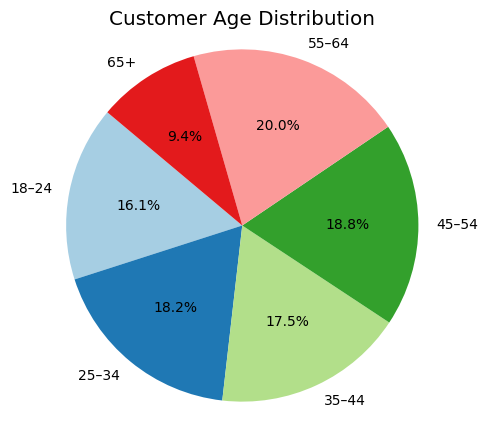

In [12]:
#Plot pie chart
plt.figure(figsize=(5, 5))
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Customer Age Distribution')
plt.axis('equal')
plt.show()


In [13]:
#Data Integration
data2 = pd.merge(demo, churn, on='CustomerID')

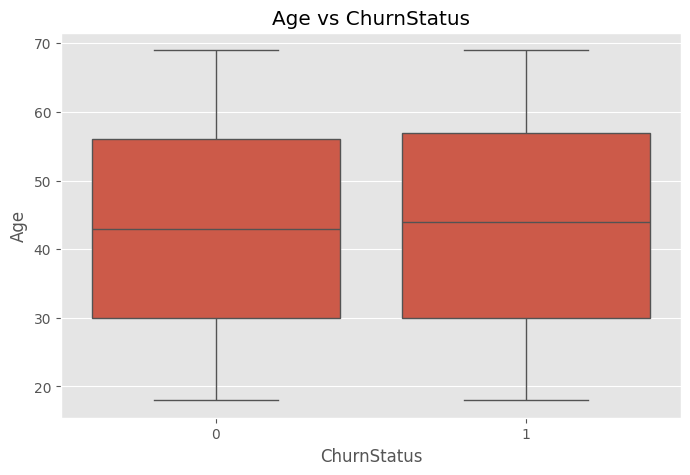

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=data2, x='ChurnStatus', y='Age')
plt.title('Age vs ChurnStatus')
plt.show()

In [15]:
data2['ChurnStatus'].value_counts()

ChurnStatus
0    796
1    204
Name: count, dtype: int64

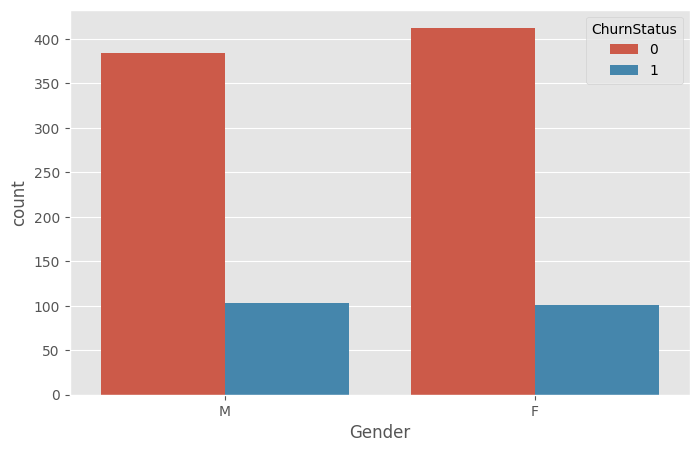

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Gender', hue='ChurnStatus', data=data2)
plt.show()

In [17]:
#Drop columns that are just IDs or not directly useful
data_cleaned = data.drop(['CustomerID', 'TransactionID', 'TransactionDate', 
                      'InteractionID', 'InteractionDate', 'LastLoginDate', 'ProductCategory'], axis=1)
data_cleaned.head()

,Age,Gender,MaritalStatus,IncomeLevel,AmountSpent,InteractionType,ResolutionStatus,LoginFrequency,ServiceUsage,ChurnStatus
0,55–64,M,Single,Low,416.50,Inquiry,Resolved,34,Mobile App,0
1,65+,M,Married,Low,54.96,Inquiry,Resolved,5,Website,1
2,65+,M,Married,Low,197.50,Inquiry,Resolved,5,Website,1
3,65+,M,Married,Low,101.31,Inquiry,Resolved,5,Website,1
4,65+,M,Married,Low,397.37,Inquiry,Resolved,5,Website,1


In [18]:
data_cleaned.shape

(5204, 10)

In [19]:
data_cleaned.describe()

,AmountSpent,LoginFrequency,ChurnStatus
count,5204.000000,5204.000000,5204.000000
mean,254.354940,25.918332,0.205995
std,143.329654,14.110627,0.404466
min,5.180000,1.000000,0.000000
25%,128.940000,14.000000,0.000000
50%,255.175000,27.000000,0.000000
75%,378.605000,38.000000,0.000000
max,499.700000,49.000000,1.000000


In [20]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5204 entries, 0 to 5203
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Age               5204 non-null   category
 1   Gender            5204 non-null   object  
 2   MaritalStatus     5204 non-null   object  
 3   IncomeLevel       5204 non-null   object  
 4   AmountSpent       5204 non-null   float64 
 5   InteractionType   5204 non-null   object  
 6   ResolutionStatus  5204 non-null   object  
 7   LoginFrequency    5204 non-null   int64   
 8   ServiceUsage      5204 non-null   object  
 9   ChurnStatus       5204 non-null   int64   
dtypes: category(1), float64(1), int64(2), object(6)
memory usage: 371.3+ KB


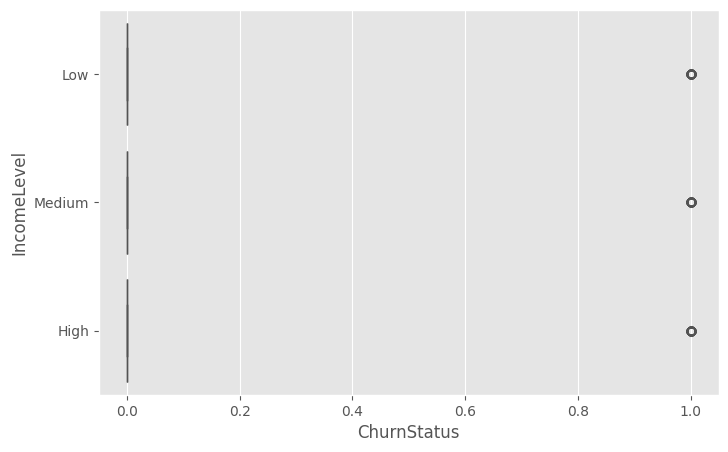

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='ChurnStatus', y='IncomeLevel', data=data2)
plt.show()

In [22]:
data_cleaned.isnull().sum()

Age                 0
Gender              0
MaritalStatus       0
IncomeLevel         0
AmountSpent         0
InteractionType     0
ResolutionStatus    0
LoginFrequency      0
ServiceUsage        0
ChurnStatus         0
dtype: int64

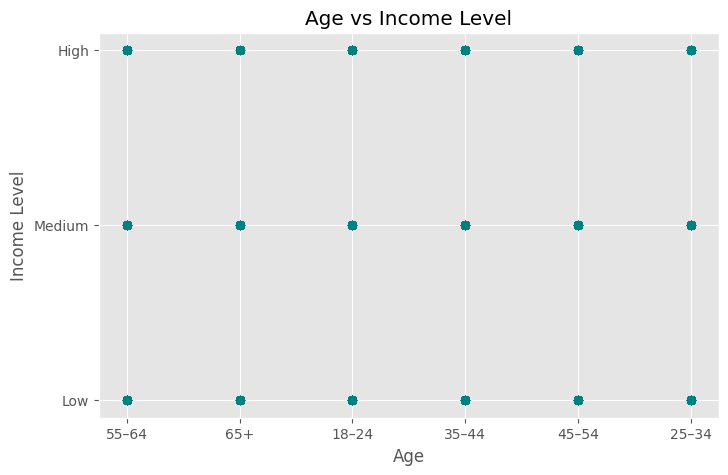

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(data_cleaned['Age'], data['IncomeLevel'], alpha=0.7, color='teal')
plt.title('Age vs Income Level')
plt.xlabel('Age')
plt.ylabel('Income Level')
plt.grid(True)
plt.show()

In [24]:
data_cleaned.select_dtypes( include = 'number').corr()

,AmountSpent,LoginFrequency,ChurnStatus
AmountSpent,1.000000,0.034658,-0.000230
LoginFrequency,0.034658,1.000000,-0.096564
ChurnStatus,-0.000230,-0.096564,1.000000


<Axes: >

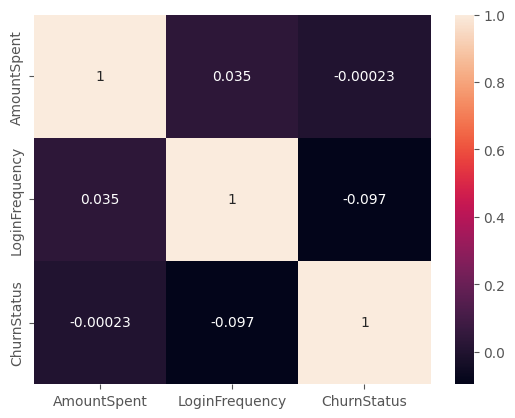

In [25]:
sns.heatmap(data_cleaned.select_dtypes( include = 'number').corr(),annot=True)

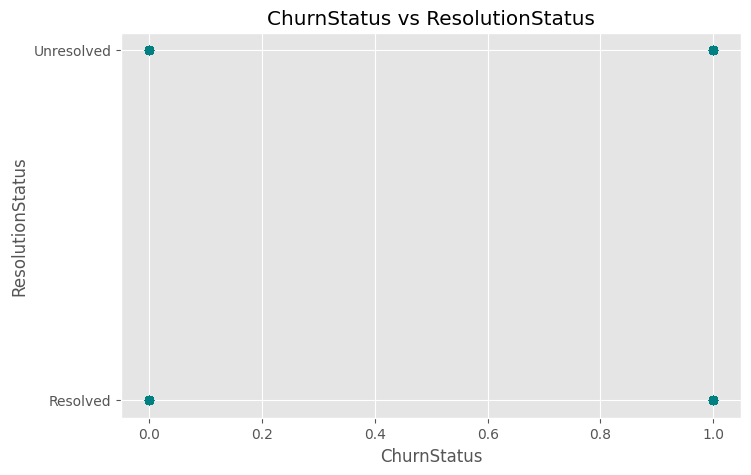

In [26]:
plt.figure(figsize=(8,5))
plt.scatter(data_cleaned['ChurnStatus'], data['ResolutionStatus'], alpha=0.7, color='teal')
plt.title('ChurnStatus vs ResolutionStatus')
plt.xlabel('ChurnStatus')
plt.ylabel('ResolutionStatus')
plt.grid(True)
plt.show()


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

In [32]:
le = LabelEncoder()
data['Gender'] = le.fit_transform(data['Gender'])
X = data_cleaned.drop('ChurnStatus', axis=1)
y = data['ChurnStatus']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [100]:
# One-hot encode all object/string columns
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_train_encoded


,AmountSpent,LoginFrequency,Age_25–34,Age_35–44,Age_45–54,Age_55–64,Age_65+,Gender_M,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium,InteractionType_Feedback,InteractionType_Inquiry,ResolutionStatus_Unresolved,ServiceUsage_Online Banking,ServiceUsage_Website
557,121.88,30,False,False,False,False,True,False,False,False,True,True,False,False,True,True,False,True
2601,110.70,48,False,False,False,False,True,True,True,False,False,False,False,True,False,True,False,False
4336,65.05,3,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False
4851,426.66,29,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,True
4957,462.43,39,False,True,False,False,False,False,True,False,False,True,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2961,321.36,21,True,False,False,False,False,False,False,False,True,False,True,False,True,False,False,False
4909,307.35,24,True,False,False,False,False,True,False,False,True,False,True,True,False,False,False,False
1483,69.63,6,False,False,False,True,False,True,False,False,False,False,True,False,True,False,False,False
1437,20.92,1,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False


In [101]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

In [102]:
# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [103]:
print("Model training successful ✅")

Model training successful ✅


In [105]:
#Predict using test data
y_pred = model.predict(X_test)

In [107]:
#For AUC, get probability estimates
y_prob = model.predict_proba(X_test)[:, 1]

In [108]:
#Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)


C:\Users\Oscar\miniconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [109]:
#Print results
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
print(f"AUC-ROC: {auc:.2f}")


Accuracy: 0.79
Precision: 0.00
Recall: 0.00
F1-score: 0.00
AUC-ROC: 0.61


In [110]:
#Get prediction probabilities for the positive class
y_prob = model.predict_proba(X_test)[:, 1]

In [111]:
#Calculate False Positive Rate, True Positive Rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

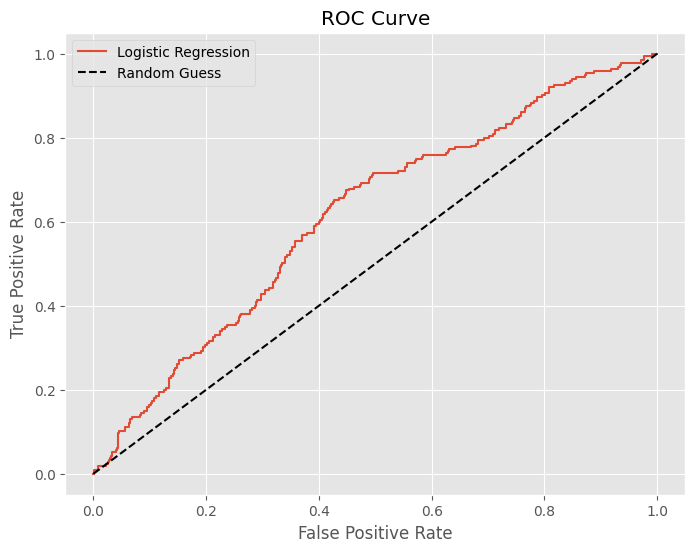

In [112]:
#Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='Logistic Regression')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [81]:
print(y_test.value_counts())   

ChurnStatus
0    826
1    215
Name: count, dtype: int64


In [113]:
#Check the shape of your train/test sets: X_train.shape, X_test.shape
print("Predictions:", y_pred[:10])
print("Actual:", y_test[:10].values)
   

Predictions: [0 0 0 0 0 0 0 0 0 0]
Actual: [0 0 0 0 1 0 1 0 0 1]


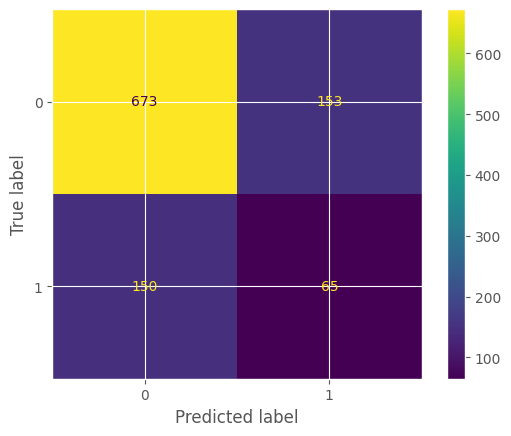

In [130]:
#Using a Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

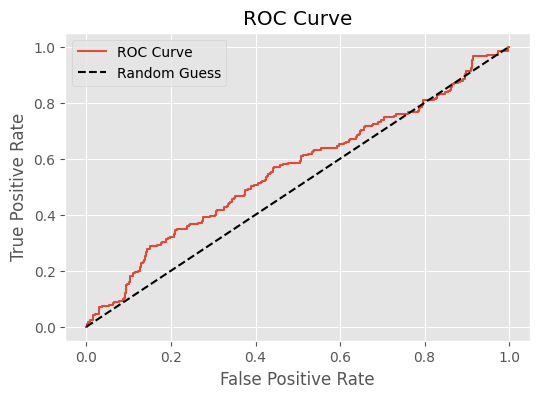

In [131]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

y_proba = model.predict_proba(X_test)[:, 1]  # Get predicted probabilities for class 1
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [132]:
print(y_proba[:10])

[0.03007659 0.4363646  0.13115569 0.35865876 0.53203122 0.22831243
 0.31553201 0.74565248 0.3047455  0.22493789]


In [133]:
print(y_train.value_counts())
print(set(y_train))

#And try scaling numeric features:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ChurnStatus
0    3306
1     857
Name: count, dtype: int64
{0, 1}


In [134]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (4163, 18)
Test shape: (1041, 18)


In [135]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_bal, y_train_bal)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [136]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred))

Accuracy: 0.7070124879923151
Precision: 0.2897196261682243
Recall: 0.28837209302325584
F1-score: 0.289044289044289
AUC-ROC: 0.5521763612816036


In [137]:
#Using SMOTE
from imblearn.over_sampling import SMOTE

In [138]:
#Assume X_train and y_train are your features and labels
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [139]:
from collections import Counter
print(Counter(y_train))
print(Counter(y_train_bal))  

Counter({0: 3306, 1: 857})
Counter({0: 3306, 1: 3306})


In [141]:
#Using balanced data after SMOTE to train the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

In [142]:
#Predict on test set
y_pred = model.predict(X_test)

#Prediction probabilities for AUC-ROC
y_prob = model.predict_proba(X_test)[:, 1]


In [143]:
#Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)


In [144]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("AUC-ROC:", auc)

Accuracy: 0.7070124879923151
Precision: 0.2897196261682243
Recall: 0.28837209302325584
F1-score: 0.289044289044289
AUC-ROC: 0.5507404696210372


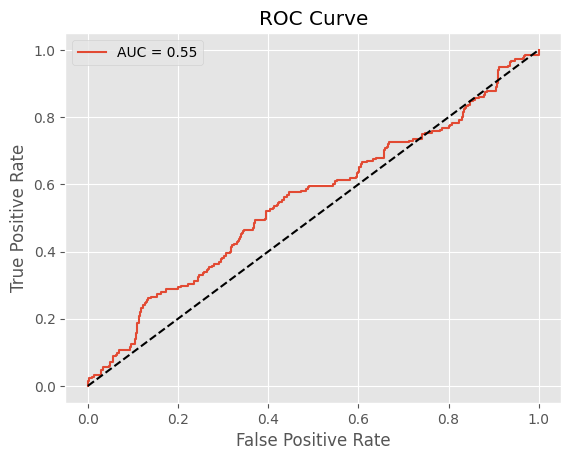

In [145]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label='AUC = %0.2f' % auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()